In [1]:
from langgraph.graph import StateGraph,START,END
from typing_extensions import TypedDict
from langgraph.graph import add_messages
from typing import Annotated

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY") # type: ignore
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY") # type: ignore


In [4]:
from langchain_openai import ChatOpenAI
llm_openai=ChatOpenAI(model="gpt-5.4-mini")
llm_openai.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DkTRupcTV73yyeSa43Z4QvIAU8a1a', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e6e66-6041-7ef2-bac3-ed09cb222e3f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_groq import ChatGroq
llm_groq=ChatGroq(model="llama-3.1-8b-instant")
llm_groq.invoke("Hello")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.010987339, 'completion_tokens_details': None, 'prompt_time': 0.001610377, 'prompt_tokens_details': None, 'queue_time': 0.051102593, 'total_time': 0.012597716}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e66-6818-71e0-a1a3-55217ad8e240-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

In [6]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

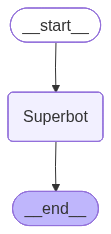

In [7]:
graph=StateGraph(State)

##node
graph.add_node("Superbot",superbot)

## edges

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image,display

## view
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:

config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hello my name is Shub and i like cricket"},config=config) # type: ignore

{'messages': [HumanMessage(content='Hello my name is Shub and i like cricket', additional_kwargs={}, response_metadata={}, id='f80e9693-83a6-4e26-b8ad-2cc8b7dc9150'),
  AIMessage(content='Hello Shub. Cricket is a wonderful sport, with a huge following worldwide. Which team or player is your favorite in international cricket? Or do you prefer domestic cricket in your country?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 45, 'total_tokens': 83, 'completion_time': 0.249585615, 'completion_tokens_details': None, 'prompt_time': 0.002770563, 'prompt_tokens_details': None, 'queue_time': 0.050055522, 'total_time': 0.252356178}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e6a-6a84-7812-a225-1bf3016d9de3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_token

### Stream

In [10]:
config={"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({"messages":"Hello my name is Shub and i like cricket"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content='Hello Shub, nice to meet you. Cricket is a fantastic sport with a huge following worldwide. Which team do you support, or do you have a favorite player? Are you more into international cricket or domestic leagues like the Indian Premier League (IPL) or the Big Bash League (BBL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 45, 'total_tokens': 107, 'completion_time': 0.079892319, 'completion_tokens_details': None, 'prompt_time': 0.003140944, 'prompt_tokens_details': None, 'queue_time': 0.157828835, 'total_time': 0.083033263}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e6c-da6c-7102-8f09-8eea4904f08d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 62, 'total_tokens': 107})]}}


In [11]:
for chunk in graph_builder.stream({"messages":"Hello my name is Shub and i like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello my name is Shub and i like cricket', additional_kwargs={}, response_metadata={}, id='5776ae9f-8252-4afb-ba59-37e7d38ead5a'), AIMessage(content='Hello Shub, nice to meet you. Cricket is a fantastic sport with a huge following worldwide. Which team do you support, or do you have a favorite player? Are you more into international cricket or domestic leagues like the Indian Premier League (IPL) or the Big Bash League (BBL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 45, 'total_tokens': 107, 'completion_time': 0.079892319, 'completion_tokens_details': None, 'prompt_time': 0.003140944, 'prompt_tokens_details': None, 'queue_time': 0.157828835, 'total_time': 0.083033263}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e6c-da6c-7102-8f09-8eea4904f08d-0'

In [12]:
for chunk in graph_builder.stream({"messages":"I also like football"},config,stream_mode="updates"):
    print(chunk)

{'Superbot': {'messages': [AIMessage(content="You're a dual sports fan, nice. Both cricket and football (or soccer, as some people call it) have a huge global following. Which football league or team do you support? Is it the English Premier League, La Liga, the UEFA Champions League, or perhaps the Indian Super League?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 176, 'total_tokens': 237, 'completion_time': 0.133492432, 'completion_tokens_details': None, 'prompt_time': 0.049155223, 'prompt_tokens_details': None, 'queue_time': 0.056836087, 'total_time': 0.182647655}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e6e-70d5-7a02-86e0-551fdedcd010-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 176, 'output_tokens': 61, 'total_tokens': 237})]}}


In [13]:
for chunk in graph_builder.stream({"messages":"I Loves Sports"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello my name is Shub and i like cricket', additional_kwargs={}, response_metadata={}, id='5776ae9f-8252-4afb-ba59-37e7d38ead5a'), AIMessage(content='Hello Shub, nice to meet you. Cricket is a fantastic sport with a huge following worldwide. Which team do you support, or do you have a favorite player? Are you more into international cricket or domestic leagues like the Indian Premier League (IPL) or the Big Bash League (BBL)?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 45, 'total_tokens': 107, 'completion_time': 0.079892319, 'completion_tokens_details': None, 'prompt_time': 0.003140944, 'prompt_tokens_details': None, 'queue_time': 0.157828835, 'total_time': 0.083033263}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6e6c-da6c-7102-8f09-8eea4904f08d-0'

### Stream using astrem method

In [14]:
config={"configurable":{"thread_id":"3"}}
async for event in graph_builder.astream_events({"messages":"My name is Shub"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'My name is Shub'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e6e75-165f-7a00-a07c-eae4379b0e4b', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='My name is Shub', additional_kwargs={}, response_metadata={}, id='00a7f574-acdd-487d-a03c-e3d8a5c94199')]}}, 'name': 'Superbot', 'tags': ['graph:step:1'], 'run_id': '019e6e75-1662-74e0-8d6a-f29bc9dd084e', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpoint_ns': 'Superbot:91bcaa6b-79b1-f883-6baf-9f30d3c3d196'}, 'parent_ids': ['019e6e75-165f-7a00-a07c-eae4379b0e4b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='My name is Shub', additional_kwargs={},